In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-12-16 21:10:59.063402


#### Functions

#### Constants

In [3]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

Project: 20241112-simple-model-test
Task: 09_15_in_60


#### Make output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import model scores

In [5]:
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df = pd.read_parquet(str_local_path)
# show
df

,accountid,request_datetime,response_model_name,yhat_ml_logistic_scorecard
0,8211697,2024-12-08 01:38:28+00:00,PRESTIGE-GEN-XII,0.116122
1,8315912,2024-12-04 00:16:24+00:00,PRESTIGE-GEN-XII,0.111542
2,8323560,2024-12-06 00:45:28+00:00,PRESTIGE-GEN-XII,0.171425
3,8332159,2024-12-06 23:32:31+00:00,PRESTIGE-GEN-XII,0.305018
4,8337838,2024-12-05 01:21:04+00:00,PRESTIGE-GEN-XII,0.143952
...,...,...,...,...
995,8472730,2024-12-08 06:33:43+00:00,PRESTIGE-GEN-XII,0.182745
996,8472731,2024-12-08 06:33:47+00:00,PRESTIGE-GEN-XII,0.231619
997,8472750,2024-12-08 06:41:36+00:00,PRESTIGE-GEN-XII,0.170825
998,8472773,2024-12-08 06:51:07+00:00,PRESTIGE-GEN-XII,0.262573


#### Import arrays for model scores

In [6]:
list_str_filename = [
    'yhat_ml_logistic_scorecard',
]
dict_arrays_quantiles_model = {}
for str_filename in tqdm(list_str_filename):
    str_filename_new = f'arr_score_quantiles_{str_filename}.pkl'
    str_local_path = f'../03_get_predictions/output/{str_filename_new}'
    arr_quantiles = pickle.load(open(str_local_path, 'rb'))
    dict_arrays_quantiles_model[str_filename] = arr_quantiles

100%|██████████| 1/1 [00:00<00:00, 4644.85it/s]


#### Import array for pricing

In [7]:
str_filename = 'arr_score_quantiles_ecnl.pkl'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
arr_score_quantile_pricing = pickle.load(open(str_local_path, 'rb'))

#### Interpolate

In [8]:
for key, val in tqdm(dict_arrays_quantiles_model.items()):
    # map quantiles and transform data
    list_mapped_data = list(np.interp(
        x=list(df[key]), 
        xp=val,
        fp=arr_score_quantile_pricing,
    ))
    # assign
    df[f'{key}_mapped_ecnl'] = list_mapped_data
# show
df

100%|██████████| 1/1 [00:00<00:00, 509.57it/s]


,accountid,request_datetime,response_model_name,yhat_ml_logistic_scorecard,yhat_ml_logistic_scorecard_mapped_ecnl
0,8211697,2024-12-08 01:38:28+00:00,PRESTIGE-GEN-XII,0.116122,0.175046
1,8315912,2024-12-04 00:16:24+00:00,PRESTIGE-GEN-XII,0.111542,0.161494
2,8323560,2024-12-06 00:45:28+00:00,PRESTIGE-GEN-XII,0.171425,0.304637
3,8332159,2024-12-06 23:32:31+00:00,PRESTIGE-GEN-XII,0.305018,0.650430
4,8337838,2024-12-05 01:21:04+00:00,PRESTIGE-GEN-XII,0.143952,0.238451
...,...,...,...,...,...
995,8472730,2024-12-08 06:33:43+00:00,PRESTIGE-GEN-XII,0.182745,0.328197
996,8472731,2024-12-08 06:33:47+00:00,PRESTIGE-GEN-XII,0.231619,0.446615
997,8472750,2024-12-08 06:41:36+00:00,PRESTIGE-GEN-XII,0.170825,0.303972
998,8472773,2024-12-08 06:51:07+00:00,PRESTIGE-GEN-XII,0.262573,0.519305


#### Distributions - Scorecard

100%|██████████| 2/2 [00:00<00:00, 31.22it/s]


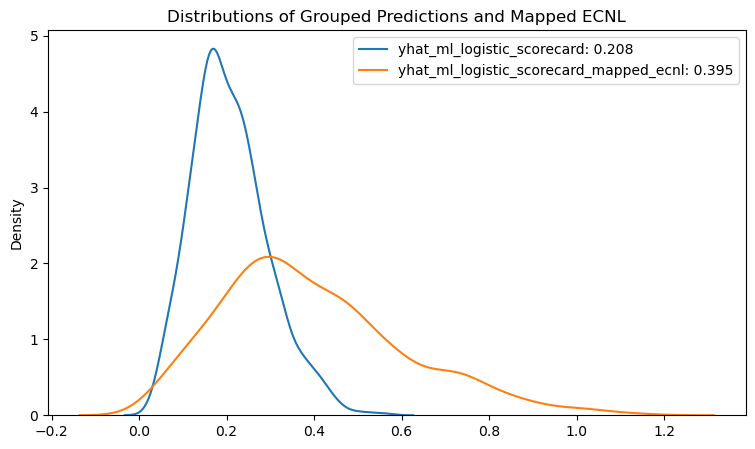

In [9]:
list_cols = [
    'yhat_ml_logistic_scorecard',
    'yhat_ml_logistic_scorecard_mapped_ecnl',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Grouped Predictions and Mapped ECNL')
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    str_label = f'{col}: {flt_mn:0.3f}'
    sns.kdeplot(list(df[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()